In [14]:
print("=" * 40)
print("   Link Budget Simulator — Results")
print("=" * 40)
print(f"  Training samples   : {len(X_train)}")
print(f"  Test samples       : {len(X_test)}")
print(f"  Model              : Random Forest (100 trees)")
print(f"  RMSE               : {rmse:.4f} Mbps")
print(f"  Top feature        : {features[np.argmax(importances)]}")
print("=" * 40)

   Link Budget Simulator — Results
  Training samples   : 400
  Test samples       : 100
  Model              : Random Forest (100 trees)
  RMSE               : 2.2821 Mbps
  Top feature        : SNR (dB)


In [13]:
import pickle, os

os.makedirs("../models", exist_ok=True)
with open("../models/link_predictor.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved to models/link_predictor.pkl")

Model saved to models/link_predictor.pkl


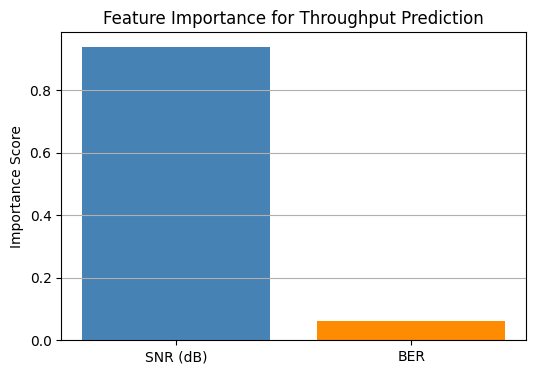

In [12]:
features = ["SNR (dB)", "BER"]
importances = model.feature_importances_

plt.figure(figsize=(6, 4))
plt.bar(features, importances, color=["steelblue", "darkorange"])
plt.title("Feature Importance for Throughput Prediction")
plt.ylabel("Importance Score")
plt.grid(axis="y")
plt.show()

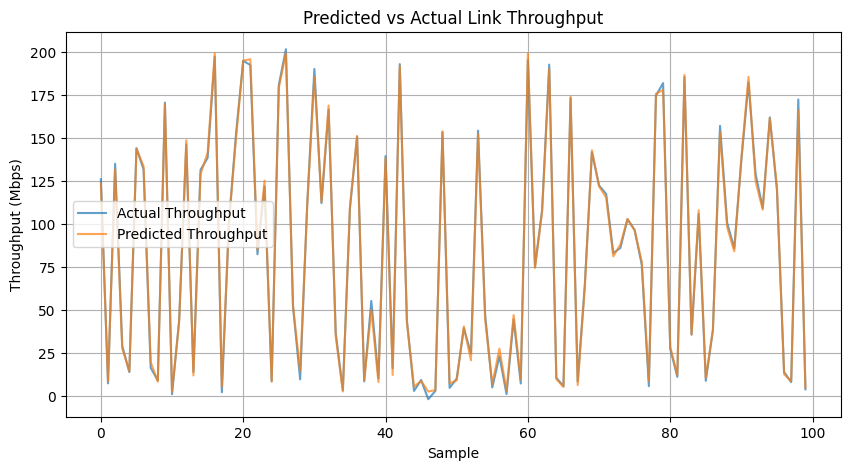

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual Throughput", alpha=0.7)
plt.plot(y_pred, label="Predicted Throughput", alpha=0.7)
plt.xlabel("Sample")
plt.ylabel("Throughput (Mbps)")
plt.title("Predicted vs Actual Link Throughput")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Model RMSE: {rmse:.4f} Mbps")

Model RMSE: 2.2821 Mbps


In [9]:
noise = np.random.normal(0, 2, size=throughput.shape)
throughput_noisy = throughput + noise

X = np.column_stack([snr_db, ber])
y = throughput_noisy

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 400
Test samples: 100


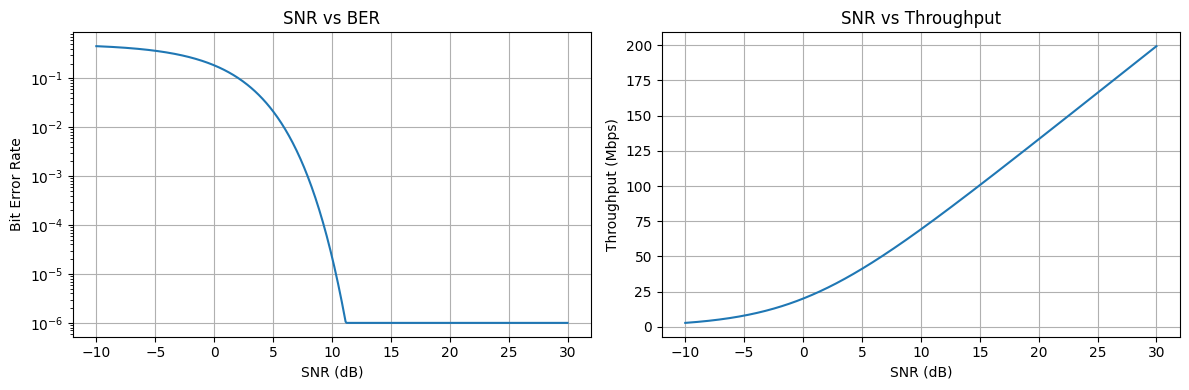

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(snr_db, ber)
ax1.set_xlabel("SNR (dB)")
ax1.set_ylabel("Bit Error Rate")
ax1.set_title("SNR vs BER")
ax1.grid(True)

ax2.plot(snr_db, throughput)
ax2.set_xlabel("SNR (dB)")
ax2.set_ylabel("Throughput (Mbps)")
ax2.set_title("SNR vs Throughput")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [2]:
snr_db = np.linspace(-10, 30, 500)
snr_linear = 10 ** (snr_db / 10)

ber = 0.5 * np.exp(-snr_linear)
ber = np.clip(ber, 1e-6, 0.5)

bandwidth_mhz = 20
throughput = bandwidth_mhz * np.log2(1 + snr_linear)

print(f"Generated {len(snr_db)} link samples")
print(f"SNR range: {snr_db.min():.1f} to {snr_db.max():.1f} dB")
print(f"Throughput range: {throughput.min():.2f} to {throughput.max():.2f} Mbps")

Generated 500 link samples
SNR range: -10.0 to 30.0 dB
Throughput range: 2.75 to 199.34 Mbps


In [1]:
import sionna
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error